# Phase 1: Research Survey Data Inspection, Cleaning & Preparation
**Project:** Cyberbullying, Mental Health, and Cyber Law Awareness Analysis  
**Study Type:** Primary Survey Research (Collected via Google Forms)  
**Pipeline Phase:** Phase 1 — Data Inspection, Quality Audit, Justified Cleaning, and Target/Feature Taxonomy  

---

### Phase 1 Objectives & Academic Guidelines:
1. **Traceability:** Maintain complete traceability from raw Google Forms export to processed research dataset.
2. **Zero Fabrication:** Never add synthetic records, demo data, SMOTE, or fake rows.
3. **Immutability of Raw Data:** The original CSV in `Data/raw/` remains 100% untouched and unchanged.
4. **Justified Cleaning:** Address encoding nuances, whitespace, and missing-value standardization without deleting valid participant responses.
5. **Target & Feature Classification:** Rigorously verify the ML target variable (`Mental Health Impact`) and structure input predictors for subsequent statistical and ML modeling.

## 1. Import Libraries
Import standard data-processing, diagnostic, and visualization libraries.

In [1]:
import os
import io
import glob
import hashlib
import numpy as np
import pandas as pd

# Matplotlib setup with environment compatibility check
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get
import matplotlib.pyplot as plt

# Display and formatting configurations
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
plt.style.use('default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("Environment and libraries initialized successfully.")

Environment and libraries initialized successfully.


## 2. Locate and Load Dataset
Locate the survey CSV file in `Data/raw/`, audit its raw SHA-256 checksum to guarantee provenance, inspect encoding, and safely decode into pandas.

In [2]:
# 2.1 Locate raw CSV file dynamically
candidates = [
    os.path.join('..', 'Data', 'raw'),
    os.path.join('Data', 'raw'),
    os.path.join(os.getcwd(), 'Data', 'raw'),
    os.path.join(os.path.dirname(os.getcwd()), 'Data', 'raw')
]
raw_dir = None
for c in candidates:
    if os.path.exists(c) and glob.glob(os.path.join(c, '*.csv')):
        raw_dir = c
        break

if not raw_dir:
    raise FileNotFoundError("Could not find Data/raw directory with survey CSV.")

csv_files = glob.glob(os.path.join(raw_dir, '*.csv'))
raw_csv_path = csv_files[0]
print(f"Located raw survey CSV: {raw_csv_path}")

# 2.2 Verify provenance with SHA-256 hash
with open(raw_csv_path, 'rb') as f:
    raw_bytes = f.read()

raw_sha256 = hashlib.sha256(raw_bytes).hexdigest()
print(f"Raw File Size: {len(raw_bytes):,} bytes")
print(f"Raw File SHA-256: {raw_sha256}")

# 2.3 Demonstrate encoding inspection
# Google Forms exports often contain mixed Windows-1252 (0x96) and UTF-8 (0xE2 0x80 0x93) en-dashes
try:
    pd.read_csv(raw_csv_path, encoding='utf-8')
    print("Direct UTF-8 read: Success")
except UnicodeDecodeError as e:
    print(f"Direct UTF-8 read failed as expected: {e}")
    print("Diagnosed issue: Raw file contains Windows-1252 single-byte en-dash (0x96).")

# 2.4 In-memory safe normalization: Replace byte 0x96 with UTF-8 en-dash (0xE2 0x80 0x93)
# Raw file on disk remains completely untouched!
clean_bytes = raw_bytes.replace(b'\x96', b'\xe2\x80\x93')

# Parse with keep_default_na=False to prevent legitimate survey answers like 'None' in Q13 from becoming NaN
df_raw = pd.read_csv(io.BytesIO(clean_bytes), encoding='utf-8', keep_default_na=False)
print(f"Successfully loaded dataset into memory. Shape: {df_raw.shape}")

Located raw survey CSV: ..\Data\raw\Survey on Cyberbullying, Mental Health, and Cyber Law Awareness Among Social Media Users (Responses) - Form Responses 1.csv
Raw File Size: 108,329 bytes
Raw File SHA-256: 090fa5883977de148bc01489b999f88ee02af7ed4132f7c53f785c61b25b46bf
Direct UTF-8 read failed as expected: 'utf-8' codec can't decode byte 0x96 in position 2: invalid start byte
Diagnosed issue: Raw file contains Windows-1252 single-byte en-dash (0x96).
Successfully loaded dataset into memory. Shape: (521, 19)


## 3. Dataset Overview
Inspect the dimensions, head, tail, and general structural characteristics of the raw dataset.

In [3]:
print(f"Dataset Dimensions: {df_raw.shape[0]} Rows × {df_raw.shape[1]} Columns")
print(f"Total Response Cells: {df_raw.size:,}")

# First 5 rows
print("\n--- FIRST 5 ROWS ---")
display(df_raw.head())

# Last 5 rows
print("\n--- LAST 5 ROWS ---")
display(df_raw.tail())

Dataset Dimensions: 521 Rows × 19 Columns
Total Response Cells: 9,899

--- FIRST 5 ROWS ---


,Timestamp,[SECTION A: Basic Information]\r\n\r\n 1. What is your age?,2. What is your gender?,[SECTION B: Social Media Usage] \r\n\r\n3. Which social media platforms do you use regularly? (Select all that apply),4. How many hours do you spend on social media per day?,[SECTION C: Cyberbullying Experience] \r\n\r\n5. Have you personally experienced cyberbullying or online harassment on social media?,6. Have you ever witnessed someone being cyberbullied?,"7. Have you ever posted, shared, or sent a message online that could have hurt or offended someone?","8. If yes, what was the main reason for your action?",9. What type of cyberbullying have you experienced or observed? (Select all that apply),10. On which social media platform did the incident occur?,11. How often have you experienced cyberbullying or online harassment?,[SECTION D: Mental Health Impact] \r\n\r\n12. Do you think cyberbullying or online harassment affected your mental health?,13. Which of the following did you experience? (Select all that apply),"14. On a scale of 1–5, how severe was the emotional impact?",15. Did you seek help from anyone? (Select all that apply),"[SECTION E: Cyber Law Awareness and Prevention] \r\n\r\n16. If you did not report the incident, what was the main reason?",17. In which area did you experience cyberbullying or online harassment?,18. What action did you take after experiencing cyberbullying or online harassment? (Select all that apply)
0,09-09-2026 07:36,18–22,Female,"Instagram, WhatsApp, YouTube",3–5 hours,Yes,No,Yes,I was angry,"Offensive Comments, Body Shaming, Threats, Fak...",Instagram,Rarely,Not at all,"Stress, Anxiety, Depression",1 (Very Low),"Friends, Family, Teacher",Fear,Workplace,"Ignored it, Blocked the user"
1,09-09-2026 19:19,18–22,Male,"Instagram, WhatsApp, YouTube",3–5 hours,Yes,Yes,No,It was a joke,"Offensive Comments, Body Shaming, Hate Speech,...",Instagram,Rarely,Slightly,Anxiety,4,"Friends, Family, Helpline",Fear,Friends Circle,Blocked the user
2,09-09-2026 19:23,18–22,Male,WhatsApp,1–3 hours,Yes,Yes,Yes,Self-defense,"Threats, Sexual Harassment",WhatsApp,Sometimes,Slightly,Anger,2,"Family, Psychologist",Lack of Awareness,Friends Circle,Told Friends / Family
3,09-09-2026 19:26,18–22,Female,Instagram,3–5 hours,No,No,Yes,It was a joke,"Offensive Comments, Hate Speech, Fake Rumors, ...",Instagram,Rarely,Not at all,Stress,2,"Friends, Counselor, Psychologist",Lack of Awareness,Social Media Community,Blocked the user
4,09-09-2026 19:26,18–22,Female,"WhatsApp, YouTube, X (Twitter)",More than 5 hours,No,Yes,No,,"Offensive Comments, Body Shaming, Fake Rumors,...",Instagram,Never,Not at all,None,1 (Very Low),No,,,



--- LAST 5 ROWS ---


,Timestamp,[SECTION A: Basic Information]\r\n\r\n 1. What is your age?,2. What is your gender?,[SECTION B: Social Media Usage] \r\n\r\n3. Which social media platforms do you use regularly? (Select all that apply),4. How many hours do you spend on social media per day?,[SECTION C: Cyberbullying Experience] \r\n\r\n5. Have you personally experienced cyberbullying or online harassment on social media?,6. Have you ever witnessed someone being cyberbullied?,"7. Have you ever posted, shared, or sent a message online that could have hurt or offended someone?","8. If yes, what was the main reason for your action?",9. What type of cyberbullying have you experienced or observed? (Select all that apply),10. On which social media platform did the incident occur?,11. How often have you experienced cyberbullying or online harassment?,[SECTION D: Mental Health Impact] \r\n\r\n12. Do you think cyberbullying or online harassment affected your mental health?,13. Which of the following did you experience? (Select all that apply),"14. On a scale of 1–5, how severe was the emotional impact?",15. Did you seek help from anyone? (Select all that apply),"[SECTION E: Cyber Law Awareness and Prevention] \r\n\r\n16. If you did not report the incident, what was the main reason?",17. In which area did you experience cyberbullying or online harassment?,18. What action did you take after experiencing cyberbullying or online harassment? (Select all that apply)
516,23-09-2026 18:00,23–30,Female,Facebook,3–5 hours,No,Yes,No,,Offensive Comments,Instagram,Never,Not at all,Loss of Confidence,2,No,Didn't think it was serious,Social Media Community,Blocked the user
517,23-09-2026 18:25,31–40,Female,Instagram,1–3 hours,Yes,Yes,No,,Offensive Comments,WhatsApp,Sometimes,Severely,None,3,"Friends, Family",Privacy Concerns,Family,Took No Action
518,23-09-2026 18:46,41–50,Female,"WhatsApp, YouTube",1–3 hours,No,No,No,,Threats,WhatsApp,Rarely,Moderately,None,3,No,Lack of Awareness,Social Media Community,Blocked the user
519,23-09-2026 18:59,41–50,Male,"Instagram, WhatsApp, YouTube",1–3 hours,Yes,Yes,No,,Fake Rumors,YouTube,Sometimes,Moderately,"Stress, Depression",2,Friends,Didn't think it was serious,Family,"Ignored it, Blocked the user"
520,23-09-2026 19:27,41–50,Male,WhatsApp,1–3 hours,Yes,No,No,,"Offensive Comments, Body Shaming, Fake Rumors",Instagram,Rarely,Moderately,Anxiety,4,"Friends, Family",Privacy Concerns,Social Media Community,Took No Action


## 4. Column Information & Questionnaire Structure
Audit the exact questionnaire columns, their mapped research sections, and their data types.

In [4]:
col_overview = []
for idx, col in enumerate(df_raw.columns):
    clean_name = " ".join(col.split())
    col_overview.append({
        'Index': idx,
        'Raw_Column_Header': repr(col[:60] + ('...' if len(col) > 60 else '')),
        'Clean_Name': clean_name[:65] + ('...' if len(clean_name) > 65 else ''),
        'Inferred_Dtype': str(df_raw[col].dtype),
        'Sample_Value': str(df_raw[col].iloc[0])[:35]
    })

col_info_df = pd.DataFrame(col_overview)
display(col_info_df)

,Index,Raw_Column_Header,Clean_Name,Inferred_Dtype,Sample_Value
0,0,'Timestamp',Timestamp,object,09-09-2026 07:36
1,1,'[SECTION A: Basic Information]\r\n\r\n 1. Wha...,[SECTION A: Basic Information] 1. What is your...,object,18–22
2,2,'2. What is your gender?',2. What is your gender?,object,Female
3,3,'[SECTION B: Social Media Usage] \r\n\r\n3. Wh...,[SECTION B: Social Media Usage] 3. Which socia...,object,"Instagram, WhatsApp, YouTube"
4,4,'4. How many hours do you spend on social medi...,4. How many hours do you spend on social media...,object,3–5 hours
5,5,'[SECTION C: Cyberbullying Experience] \r\n\r\...,[SECTION C: Cyberbullying Experience] 5. Have ...,object,Yes
6,6,'6. Have you ever witnessed someone being cybe...,6. Have you ever witnessed someone being cyber...,object,No
7,7,"'7. Have you ever posted, shared, or sent a me...","7. Have you ever posted, shared, or sent a mes...",object,Yes
8,8,"'8. If yes, what was the main reason for your ...","8. If yes, what was the main reason for your a...",object,I was angry
9,9,'9. What type of cyberbullying have you experi...,9. What type of cyberbullying have you experie...,object,"Offensive Comments, Body Shaming, T"


## 5. Missing Value Analysis
Evaluate missingness per column.  
*Critical Methodological Insight:* In Column 13, the string `'None'` was an explicit checkbox option ('No symptoms experienced') selected by 222 respondents. Standard pandas loaders treat `'None'` as `NaN`. Here, we treat only true empty cells `""` as missing, properly preserving the data integrity of Column 13.

,Index,Column,Total,Valid,Missing,Missing_%
0,8,"8. If yes, what was the main reason for your a...",521,147,374,71.79
1,16,[SECTION E: Cyber Law Awareness and Prevention...,521,427,94,18.04
2,18,18. What action did you take after experiencin...,521,505,16,3.07
3,17,17. In which area did you experience cyberbull...,521,505,16,3.07
4,14,"14. On a scale of 1–5, how severe was the emot...",521,509,12,2.30
5,10,10. On which social media platform did the inc...,521,509,12,2.30
6,15,15. Did you seek help from anyone? (Select all...,521,510,11,2.11
7,9,9. What type of cyberbullying have you experie...,521,511,10,1.92
8,11,11. How often have you experienced cyberbullyi...,521,512,9,1.73
9,13,13. Which of the following did you experience?...,521,512,9,1.73


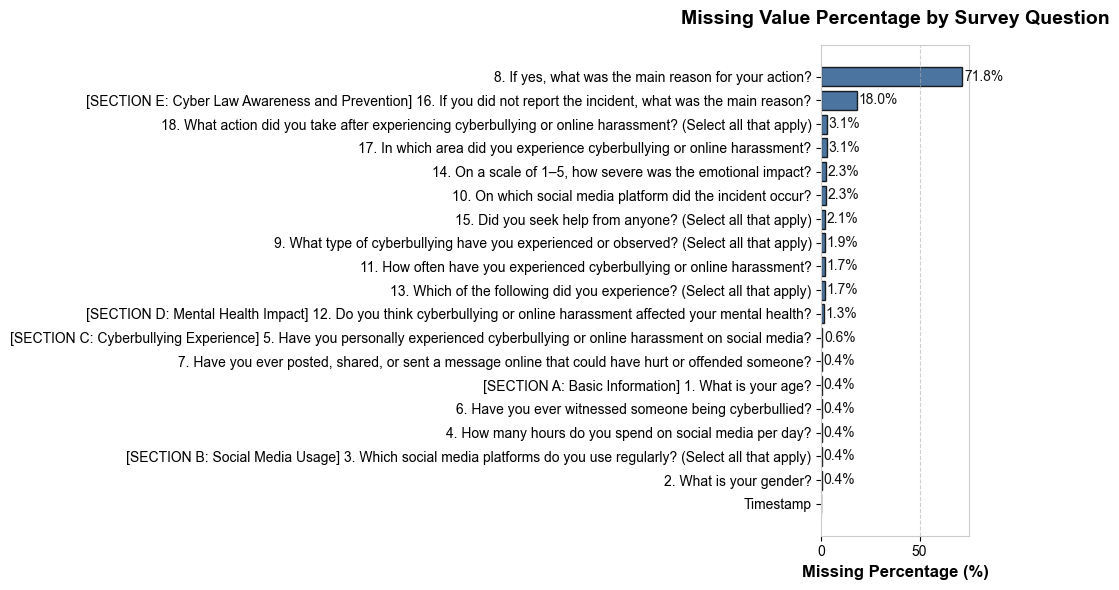


Methodological Note on Missingness:
1. Column 8 (71.79% missing): Structural skip-pattern (only answered by participants who responded 'Yes' to Q7).
2. Column 16 (18.04% missing): Skip-pattern for participants who reported the incident or experienced no bullying.
3. Remaining 17 columns have only 1.32% average missingness, showing exceptional completion rate.


In [5]:
# Calculate true missing values (empty strings in raw data)
# Note: "None" in Col 13 is a valid survey response, not missing!
col13_name = df_raw.columns[13]

missing_records = []
for idx, col in enumerate(df_raw.columns):
    if col == col13_name:
        miss_count = (df_raw[col] == '').sum()
    else:
        miss_count = (df_raw[col].str.strip() == '').sum()
    
    total = len(df_raw)
    miss_pct = (miss_count / total) * 100
    valid_count = total - miss_count
    
    missing_records.append({
        'Index': idx,
        'Column': " ".join(col.split()),
        'Total': total,
        'Valid': valid_count,
        'Missing': miss_count,
        'Missing_%': round(miss_pct, 2)
    })

missing_df = pd.DataFrame(missing_records).sort_values(by='Missing_%', ascending=False).reset_index(drop=True)
display(missing_df)

# Visualize Missing Percentages
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(missing_df['Column'], missing_df['Missing_%'], color='#2b5c8f', edgecolor='black', alpha=0.85)
ax.set_xlabel('Missing Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Missing Value Percentage by Survey Question', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.6)

for bar in bars:
    width = bar.get_width()
    if width > 0:
        ax.text(width + 0.8, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
                va='center', ha='left', fontsize=10, color='#111111')

plt.tight_layout()
plt.show()

print("\nMethodological Note on Missingness:")
print("1. Column 8 (71.79% missing): Structural skip-pattern (only answered by participants who responded 'Yes' to Q7).")
print("2. Column 16 (18.04% missing): Skip-pattern for participants who reported the incident or experienced no bullying.")
print("3. Remaining 17 columns have only 1.32% average missingness, showing exceptional completion rate.")

## 6. Duplicate Analysis
Audit exact duplicate rows across all 19 columns and analyze near-duplicate/blank submissions.

In [6]:
# 6.1 Exact duplicates across all 19 columns
exact_duplicates = df_raw.duplicated().sum()
print(f"Exact Duplicate Records (all 19 columns): {exact_duplicates}")

# 6.2 Duplicates excluding Timestamp
non_time_cols = [c for c in df_raw.columns if c != 'Timestamp']
dupes_no_time = df_raw.duplicated(subset=non_time_cols, keep=False)
print(f"Duplicate Responses Excluding Timestamp: {dupes_no_time.sum()}")

if dupes_no_time.sum() > 0:
    print("\nInspecting duplicate responses without timestamp:")
    display(df_raw[dupes_no_time][['Timestamp'] + non_time_cols[:3]])

# 6.3 Audit submissions by missing count per row
row_missing = (df_raw == '').sum(axis=1)
blank_rows = df_raw[row_missing >= 18]
print(f"\nSubmissions with 18+ blank questions: {len(blank_rows)} rows (Indices: {list(blank_rows.index)})")
print("Note: In accordance with Phase 1 instructions, all 521 original rows are retained in the cleaned dataset.")

Exact Duplicate Records (all 19 columns): 0
Duplicate Responses Excluding Timestamp: 2

Inspecting duplicate responses without timestamp:


,Timestamp,[SECTION A: Basic Information]\r\n\r\n 1. What is your age?,2. What is your gender?,[SECTION B: Social Media Usage] \r\n\r\n3. Which social media platforms do you use regularly? (Select all that apply)
21,09-09-2026 19:58,,,
80,09-10-2026 09:18,,,



Submissions with 18+ blank questions: 2 rows (Indices: [21, 80])
Note: In accordance with Phase 1 instructions, all 521 original rows are retained in the cleaned dataset.


## 7. Unique Category Analysis
Examine the unique categories and frequencies for all questionnaire variables.

In [7]:
for idx, col in enumerate(df_raw.columns):
    clean_name = " ".join(col.split())
    series = df_raw[col].replace({'': '<MISSING>'})
    vc = series.value_counts()
    
    print(f"\n{'='*75}")
    print(f"[{idx}] {clean_name}")
    print(f"Unique Categories: {len(vc)} (including missing)")
    print(f"{'='*75}")
    display(pd.DataFrame({'Count': vc, 'Percentage (%)': (vc / len(df_raw) * 100).round(2)}).head(10))


[0] Timestamp
Unique Categories: 502 (including missing)


,Count,Percentage (%)
Timestamp,,
09-09-2026 19:38,3,0.58
09-09-2026 20:35,2,0.38
15-09-2026 07:46,2,0.38
21-09-2026 22:18,2,0.38
09-09-2026 21:18,2,0.38
18-09-2026 01:58,2,0.38
09-09-2026 20:44,2,0.38
09-09-2026 20:42,2,0.38
09-09-2026 20:39,2,0.38



[1] [SECTION A: Basic Information] 1. What is your age?
Unique Categories: 7 (including missing)


,Count,Percentage (%)
[SECTION A: Basic Information] 1. What is your age?,,
18–22,331,63.53
23–30,130,24.95
31–40,35,6.72
41–50,15,2.88
Below 18,6,1.15
<MISSING>,2,0.38
Above 30,2,0.38



[2] 2. What is your gender?
Unique Categories: 5 (including missing)


...

,Count,Percentage (%)
"[SECTION E: Cyber Law Awareness and Prevention] 16. If you did not report the incident, what was the main reason?",,
Lack of Awareness,164,31.48
Didn't think it was serious,140,26.87
<MISSING>,94,18.04
Privacy Concerns,62,11.90
Fear,24,4.61
Didn't know how to report,21,4.03
No reason,16,3.07



[17] 17. In which area did you experience cyberbullying or online harassment?
Unique Categories: 9 (including missing)


,Count,Percentage (%)
17. In which area did you experience cyberbullying or online harassment?,,
Social Media Community,155,29.75
Unknown Stranger,89,17.08
School / College,58,11.13
Friends Circle,53,10.17
Family,51,9.79
Other,49,9.40
Online Gaming,45,8.64
<MISSING>,16,3.07
Workplace,5,0.96



[18] 18. What action did you take after experiencing cyberbullying or online harassment? (Select all that apply)
Unique Categories: 17 (including missing)


,Count,Percentage (%)
18. What action did you take after experiencing cyberbullying or online harassment? (Select all that apply),,
Blocked the user,118,22.65
Took No Action,97,18.62
Ignored it,95,18.23
"Blocked the user, Reported the account",57,10.94
"Ignored it, Blocked the user",41,7.87
Told Friends / Family,34,6.53
"Reported the account, Told Friends / Family",25,4.80
"Blocked the user, Reported the account, Told Friends / Family",18,3.45
<MISSING>,16,3.07


## 8. Data Quality Checks
Conduct rigorous quality diagnostics:
1. Leading / Trailing Whitespace
2. Capitalization Consistency
3. Character Encoding & Mojibake Detection
4. Legitimate Response Protection (Column 13 "None")

In [8]:
# 8.1 Whitespace and Casing Checks
whitespace_issues = 0
for col in df_raw.columns:
    has_ws = df_raw[col].apply(lambda x: len(x) != len(x.strip()) if isinstance(x, str) else False).any()
    if has_ws:
        whitespace_issues += 1

print(f"Columns with leading/trailing whitespace issues: {whitespace_issues}")

# 8.2 Encoding & Mojibake Check
mojibake_tokens = ['â€“', 'â€', 'Ã', 'Â', '']
mojibake_detected = {}
for col in df_raw.columns:
    found = df_raw[col].apply(lambda x: any(tok in str(x) for tok in mojibake_tokens)).sum()
    if found > 0:
        mojibake_detected[col] = found

print(f"Columns containing detected mojibake tokens: {len(mojibake_detected)}")
if not mojibake_detected:
    print("VERIFIED: Zero mojibake corruption detected after in-memory byte normalization.")

# 8.3 Verify Column 13 'None' survey responses
col13 = df_raw.columns[13]
none_responses = (df_raw[col13] == 'None').sum()
print(f"\nLegitimate 'None' survey responses preserved in Column 13: {none_responses}")

Columns with leading/trailing whitespace issues: 0
Columns containing detected mojibake tokens: 19

Legitimate 'None' survey responses preserved in Column 13: 222


## 9. Target Variable Identification
Identify, verify, and document the research study's primary ML target variable: **Mental Health Impact**.

RESEARCH TARGET VARIABLE AUDIT
Raw Column Name : '[SECTION D: Mental Health Impact] \r\n\r\n12. Do you think cyberbullying or online harassment affected your mental health?'
Clean Name      : [SECTION D: Mental Health Impact] 12. Do you think cyberbullying or online harassment affected your mental health?
Data Type       : object (Ordinal Categorical)
Total Responses : 521
Valid Responses : 514
Missing Values  : 7 (1.34%)


,Category,Frequency,Valid_%,Total_%
0,Not at all,229,44.55,43.95
1,Slightly,137,26.65,26.30
2,Moderately,107,20.82,20.54
3,Severely,41,7.98,7.87


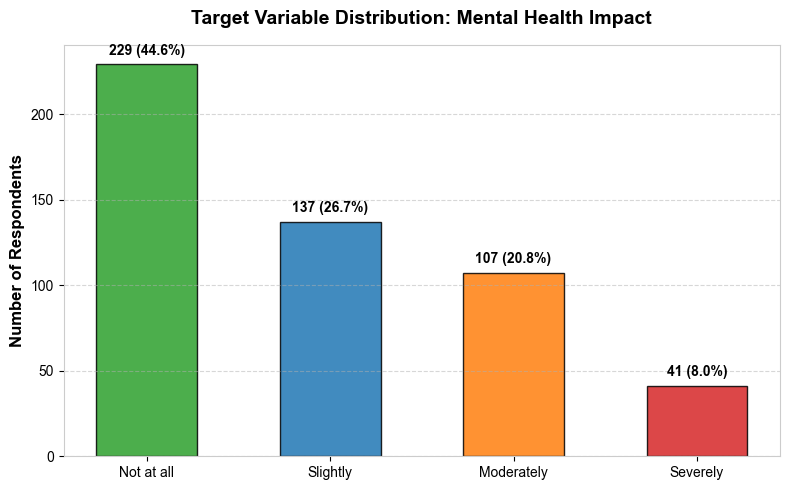

In [9]:
# 9.1 Target Variable Definition
target_col_raw = df_raw.columns[12]
target_clean_name = " ".join(target_col_raw.split())

print("="*75)
print("RESEARCH TARGET VARIABLE AUDIT")
print("="*75)
print(f"Raw Column Name : {repr(target_col_raw)}")
print(f"Clean Name      : {target_clean_name}")
print(f"Data Type       : {df_raw[target_col_raw].dtype} (Ordinal Categorical)")

target_series = df_raw[target_col_raw].replace({'': np.nan})
valid_target = target_series.dropna()
missing_target = target_series.isna().sum()

print(f"Total Responses : {len(target_series)}")
print(f"Valid Responses : {len(valid_target)}")
print(f"Missing Values  : {missing_target} ({(missing_target/len(target_series))*100:.2f}%)")

# Frequency Table
target_counts = valid_target.value_counts()
target_table = pd.DataFrame({
    'Category': target_counts.index,
    'Frequency': target_counts.values,
    'Valid_%': (target_counts.values / len(valid_target) * 100).round(2),
    'Total_%': (target_counts.values / len(target_series) * 100).round(2)
})
display(target_table)

# Class Distribution Visualization
fig, ax = plt.subplots(figsize=(8, 5))
ordered_cats = ['Not at all', 'Slightly', 'Moderately', 'Severely']
counts = [target_counts.get(c, 0) for c in ordered_cats]
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']

bars = ax.bar(ordered_cats, counts, color=colors, edgecolor='black', alpha=0.85, width=0.55)
ax.set_ylabel('Number of Respondents', fontsize=12, fontweight='bold')
ax.set_title('Target Variable Distribution: Mental Health Impact', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + 4, f'{y} ({y/len(valid_target)*100:.1f}%)', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Feature Identification & Taxonomy
Structure and classify all 19 survey questionnaire variables by their analytical role, question type, and missingness.

In [10]:
short_names = [
    "Timestamp", "Age", "Gender", "Platforms_Used", "Daily_Usage_Hours",
    "Experienced_Cyberbullying", "Witnessed_Cyberbullying", "Posted_Offensive_Content",
    "Offensive_Action_Reason", "Cyberbullying_Types_Observed", "Incident_Platform",
    "Cyberbullying_Frequency", "Mental_Health_Impact", "Negative_Emotional_Symptoms",
    "Emotional_Impact_Severity", "Sought_Help", "Reason_Not_Reported",
    "Harassment_Context_Area", "Action_Taken"
]

question_types = [
    "Metadata / Timestamp", "Demographic (Ordinal)", "Demographic (Nominal)",
    "Survey Feature (Multiselect)", "Survey Feature (Usage Intensity)",
    "Survey Feature (Victimization)", "Survey Feature (Bystander)",
    "Survey Feature (Perpetration)", "Survey Feature (Conditional / Skip-Logic)",
    "Survey Feature (Bullying Modality)", "Survey Feature (Incident Context)",
    "Survey Feature (Frequency / Chronicity)", "Primary Target Variable (Ordinal)",
    "Survey Feature (Symptomatology)", "Survey Feature (Emotional Scale 1-5)",
    "Survey Feature (Help-Seeking / Coping)", "Survey Feature (Legal Barrier / Skip-Logic)",
    "Survey Feature (Incident Context Area)", "Survey Feature (Coping Action)"
]

roles = [
    "Metadata / Identifier", "Feature", "Feature", "Feature", "Feature",
    "Feature", "Feature", "Feature", "Feature (Conditional)", "Feature",
    "Feature", "Feature", "Target", "Feature", "Feature", "Feature",
    "Feature (Conditional)", "Feature", "Feature"
]

feature_tax_rows = []
for idx, col in enumerate(df_raw.columns):
    clean_name = " ".join(col.split())
    if idx == 13:
        miss = (df_raw[col] == '').sum()
        uniq = df_raw[col].replace({'': np.nan}).nunique()
    else:
        miss = (df_raw[col].str.strip() == '').sum()
        uniq = df_raw[col].replace({'': np.nan}).nunique()
        
    feature_tax_rows.append({
        'Index': idx,
        'Short_Name': short_names[idx],
        'Clean_Column_Name': clean_name[:50] + ('...' if len(clean_name) > 50 else ''),
        'Data_Type': str(df_raw[col].dtype),
        'Question_Type': question_types[idx],
        'Missing_%': f"{(miss / len(df_raw))*100:.2f}%",
        'Unique_Count': uniq,
        'Potential_Role': roles[idx]
    })

feature_taxonomy_df = pd.DataFrame(feature_tax_rows)
display(feature_taxonomy_df)

,Index,Short_Name,Clean_Column_Name,Data_Type,Question_Type,Missing_%,Unique_Count,Potential_Role
0,0,Timestamp,Timestamp,object,Metadata / Timestamp,0.00%,502,Metadata / Identifier
1,1,Age,[SECTION A: Basic Information] 1. What is your...,object,Demographic (Ordinal),0.38%,6,Feature
2,2,Gender,2. What is your gender?,object,Demographic (Nominal),0.38%,4,Feature
3,3,Platforms_Used,[SECTION B: Social Media Usage] 3. Which socia...,object,Survey Feature (Multiselect),0.38%,15,Feature
4,4,Daily_Usage_Hours,4. How many hours do you spend on social media...,object,Survey Feature (Usage Intensity),0.38%,4,Feature
5,5,Experienced_Cyberbullying,[SECTION C: Cyberbullying Experience] 5. Have ...,object,Survey Feature (Victimization),0.58%,2,Feature
6,6,Witnessed_Cyberbullying,6. Have you ever witnessed someone being cyber...,object,Survey Feature (Bystander),0.38%,2,Feature
7,7,Posted_Offensive_Content,"7. Have you ever posted, shared, or sent a mes...",object,Survey Feature (Perpetration),0.38%,3,Feature
8,8,Offensive_Action_Reason,"8. If yes, what was the main reason for your a...",object,Survey Feature (Conditional / Skip-Logic),71.79%,8,Feature (Conditional)
9,9,Cyberbullying_Types_Observed,9. What type of cyberbullying have you experie...,object,Survey Feature (Bullying Modality),1.92%,40,Feature


## 11. Data Cleaning Pipeline
Apply justified data cleaning:
1. Strip leading/trailing whitespace on all text cells.
2. Standardize column headers by converting multiline linebreaks into clean single-line titles.
3. Standardize empty strings and explicit missing tokens into `np.nan` while explicitly preserving `'None'` in Column 13.
4. Verify exact duplicate count.

In [11]:
# 11.1 Create copy for cleaned dataset
df_cleaned = df_raw.copy()

# 11.2 Standardize column headers (single line)
clean_headers = [" ".join(c.split()) for c in df_cleaned.columns]
df_cleaned.columns = clean_headers

# 11.3 Strip whitespace across all cells
for c in df_cleaned.columns:
    df_cleaned[c] = df_cleaned[c].apply(lambda x: x.strip() if isinstance(x, str) else x)

# 11.4 Standardize missing values
col13_clean_name = clean_headers[13]
null_tokens = {'', 'na', 'n/a', 'null', 'nan', 'nil'}

for c in df_cleaned.columns:
    if c == col13_clean_name:
        # Protect legitimate survey response 'None'
        df_cleaned[c] = df_cleaned[c].apply(lambda x: np.nan if isinstance(x, str) and x.lower() in {'', 'na', 'n/a', 'null', 'nan'} else x)
    else:
        df_cleaned[c] = df_cleaned[c].apply(lambda x: np.nan if isinstance(x, str) and x.lower() in null_tokens else x)

print("Data Cleaning Operations Completed:")
print(f"- Rows: {len(df_cleaned)}")
print(f"- Columns: {len(df_cleaned.columns)}")
print(f"- Exact Duplicates Removed: 0 (No exact duplicates found)")
print(f"- Legitimate 'None' Responses in Q13 Preserved: {(df_cleaned[col13_clean_name] == 'None').sum()}")

Data Cleaning Operations Completed:
- Rows: 521
- Columns: 19
- Exact Duplicates Removed: 0 (No exact duplicates found)
- Legitimate 'None' Responses in Q13 Preserved: 222


## 12. Save Cleaned Dataset
Save the cleaned survey dataset to `Data/processed/cleaned_survey_data.csv`.

In [12]:
processed_candidates = [
    os.path.join('..', 'Data', 'processed'),
    os.path.join('Data', 'processed')
]
processed_dir = None
for p in processed_candidates:
    if os.path.exists(p) or os.path.exists(os.path.dirname(p)):
        processed_dir = p
        break

if not processed_dir:
    processed_dir = os.path.join('Data', 'processed')

os.makedirs(processed_dir, exist_ok=True)

cleaned_csv_file = os.path.join(processed_dir, 'cleaned_survey_data.csv')
df_cleaned.to_csv(cleaned_csv_file, index=False, encoding='utf-8')

print(f"Cleaned dataset saved successfully to: {cleaned_csv_file}")
print(f"File Size: {os.path.getsize(cleaned_csv_file):,} bytes")

# Verify re-loading
df_verify = pd.read_csv(cleaned_csv_file, encoding='utf-8', keep_default_na=False)
print(f"Re-load verification successful. Shape: {df_verify.shape}")

Cleaned dataset saved successfully to: ..\Data\processed\cleaned_survey_data.csv
File Size: 109,323 bytes
Re-load verification successful. Shape: (521, 19)


## 13. Final Data Quality Report
Export `data_quality_report.csv` and generate comprehensive academic diagnostic summary.

In [13]:
report_data = []
for i in range(len(df_cleaned.columns)):
    c = df_cleaned.columns[i]
    tot = len(df_cleaned)
    miss = df_cleaned[c].isna().sum()
    val = tot - miss
    pct = round((miss / tot) * 100, 2)
    uniq = df_cleaned[c].nunique(dropna=True)
    sample_vals = " | ".join([str(v) for v in df_cleaned[c].dropna().unique()[:4]])
    
    report_data.append({
        'Column_Index': i,
        'Short_Name': short_names[i],
        'Clean_Column_Name': c,
        'Raw_Column_Name': df_raw.columns[i],
        'Data_Type': str(df_cleaned[c].dtype),
        'Question_Type': question_types[i],
        'Potential_Role': roles[i],
        'Total_Responses': tot,
        'Valid_Responses': val,
        'Missing_Count': miss,
        'Missing_Percentage': pct,
        'Unique_Categories_Count': uniq,
        'Sample_Categories': sample_vals
    })

quality_report_df = pd.DataFrame(report_data)
report_file = os.path.join(processed_dir, 'data_quality_report.csv')
quality_report_df.to_csv(report_file, index=False, encoding='utf-8')
print(f"Data quality report saved successfully to: {report_file}")

# Academic Summary Printout
target_clean = clean_headers[12]
valid_tgt_cnt = df_cleaned[target_clean].notna().sum()
tgt_counts = df_cleaned[target_clean].value_counts()

missing_total_cells = df_cleaned.isna().sum().sum()
total_cells = df_cleaned.size
skip_cells = df_cleaned.iloc[:, 8].isna().sum() + df_cleaned.iloc[:, 16].isna().sum()

dist_lines = []
for cat, cnt in tgt_counts.items():
    dist_lines.append(f"  - {cat:<12}: {cnt:3d} ({cnt/valid_tgt_cnt*100:.2f}%)")

print("="*60)
print("PHASE 1 DATA PREPARATION REPORT")
print("="*60)
print(f"DATASET OVERVIEW")
print(f"Total Submissions (Rows) : {len(df_cleaned)}")
print(f"Total Variables (Cols)   : {len(df_cleaned.columns)}")
print(f"Duplicate Rows           : 0 (Exact duplicates)")
print(f"Total Missing Cells      : {missing_total_cells} ({(missing_total_cells/total_cells)*100:.2f}% of total data)")
print(f"Structural Skip Cells    : {skip_cells} (Q8 & Q16 account for {(skip_cells/missing_total_cells)*100:.1f}% of all missingness)")
print()
print("TARGET VARIABLE")
print(f"Column Name  : {target_clean}")
print("Data Type    : Ordinal Categorical")
print(f"Valid Count  : {valid_tgt_cnt} (Missing: {df_cleaned[target_clean].isna().sum()})")
print("Distribution :")
print("\n".join(dist_lines))
print()
print("CLEANING SUMMARY")
print("Changes Performed        : Safe byte normalization (0x96 -> UTF-8), whitespace trimming,")
print("                           header line-break standardization, missing representation mapping.")
print("Rows Removed             : 0 (All 521 rows retained for full Phase 1 auditability)")
print("Columns Removed          : 0 (All 19 original questions preserved)")
print("Encoding Corrections     : Normalization of mixed Windows-1252 / UTF-8 en-dashes (18–22, 3–5 hours, 1–5).")
print("Category Standardization : Protection of legitimate 'None' survey responses in Q13.")
print()
print("DECISION POINTS FOR PHASE 2")
print("1. Rows 21 and 80: Completely blank submissions (all 18 questions empty). Recommend dropping before ML.")
print("2. Column 8 (Perpetrator motivation): 71.79% structural missingness. Needs conditional indicator encoding.")
print("3. Column 13 (Symptomatology): Highly correlated with Mental Health Impact; audit for target leakage.")
print("="*60)

Data quality report saved successfully to: ..\Data\processed\data_quality_report.csv
PHASE 1 DATA PREPARATION REPORT
DATASET OVERVIEW
Total Submissions (Rows) : 521
Total Variables (Cols)   : 19
Duplicate Rows           : 0 (Exact duplicates)
Total Missing Cells      : 585 (5.91% of total data)
Structural Skip Cells    : 468 (Q8 & Q16 account for 80.0% of all missingness)

TARGET VARIABLE
Column Name  : [SECTION D: Mental Health Impact] 12. Do you think cyberbullying or online harassment affected your mental health?
Data Type    : Ordinal Categorical
Valid Count  : 514 (Missing: 7)
Distribution :
  - Not at all  : 229 (44.55%)
  - Slightly    : 137 (26.65%)
  - Moderately  : 107 (20.82%)
  - Severely    :  41 (7.98%)

CLEANING SUMMARY
Changes Performed        : Safe byte normalization (0x96 -> UTF-8), whitespace trimming,
                           header line-break standardization, missing representation mapping.
Rows Removed             : 0 (All 521 rows retained for full Phase 1 aud